In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
path = 'Human_Activity_Recognition_Using_Smartphones_Data (1).csv'
data = pd.read_csv(path , sep= ",")

In [3]:
data.dtypes.value_counts()

float64    561
object       1
Name: count, dtype: int64

In [4]:
data.dtypes.tail()

angle(tBodyGyroJerkMean,gravityMean)    float64
angle(X,gravityMean)                    float64
angle(Y,gravityMean)                    float64
angle(Z,gravityMean)                    float64
Activity                                 object
dtype: object

In [5]:
data.iloc[: , :-1].min().value_counts()

-1.0    561
Name: count, dtype: int64

In [6]:
data.iloc[: , :-1].max().value_counts()

1.0    561
Name: count, dtype: int64

In [7]:
data.Activity.value_counts()

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()
data["Activity"] = Le.fit_transform(data.Activity)
print(data["Activity"].sample(5))

7635    5
5571    0
8670    4
9540    5
8775    0
Name: Activity, dtype: int64


In [9]:
for index , class_name in enumerate(Le.classes_):
    print(f'{index} : {class_name}')

0 : LAYING
1 : SITTING
2 : STANDING
3 : WALKING
4 : WALKING_DOWNSTAIRS
5 : WALKING_UPSTAIRS


In [10]:
feature_cols = data.columns[:-1]
corr_values = data[feature_cols].corr()

trail_index = np.tril_indices_from(corr_values) # حسبنا احصائيات المثلث السفلي


In [11]:
for coord in zip(*trail_index):
    corr_values.iloc[coord[0] , coord[1]] = np.nan # فضينا المثلث السفلي

In [12]:
corr_values = (corr_values
               .stack()
               .to_frame()
               .reset_index()
               .rename(columns={'level_0':'feature1',
                                'level_1':'feature2',
                                0:'correlation'}))
corr_values['abs_correlation'] = corr_values.correlation.abs()

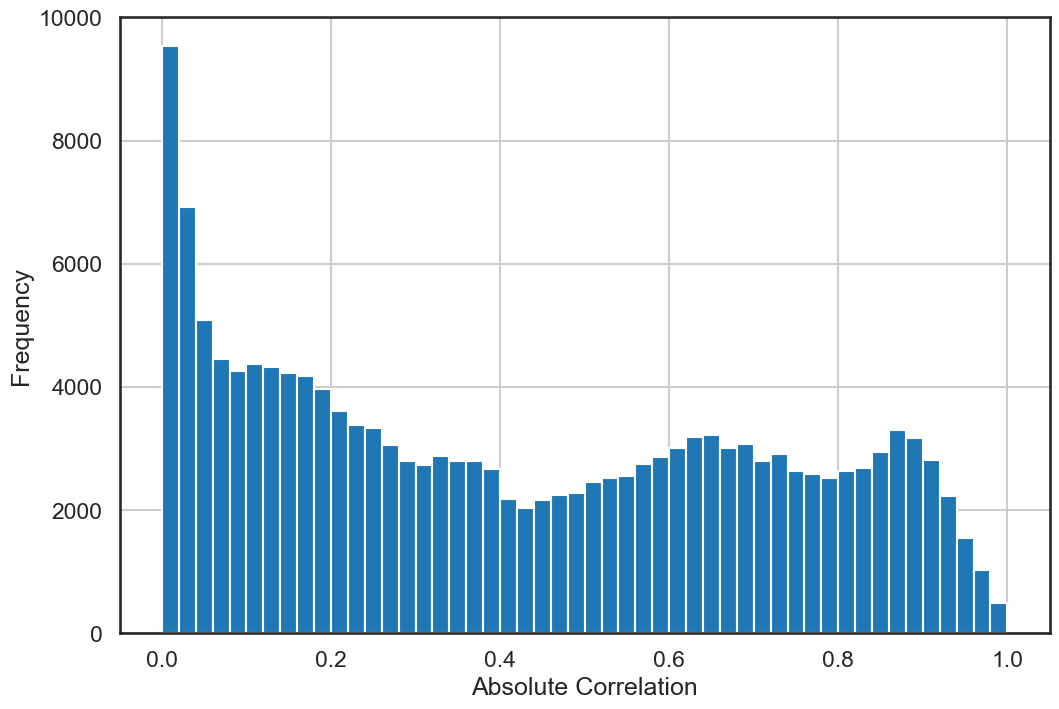

In [13]:
sns.set_context("talk")
sns.set_style("white")

ax = corr_values.abs_correlation.hist(bins=50 , figsize=(12,8))
ax.set(xlabel='Absolute Correlation', ylabel='Frequency');

In [14]:
corr_values.sort_values("correlation" , ascending=False).query("abs_correlation>0.8")

,feature1,feature2,correlation,abs_correlation
156894,fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-sma(),1.000000,1.000000
156556,fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-sma(),1.000000,1.000000
96706,tGravityAccMag-mean(),tGravityAccMag-sma(),1.000000,1.000000
96366,tBodyAccMag-arCoeff()4,tGravityAccMag-arCoeff()4,1.000000,1.000000
109498,tBodyGyroJerkMag-mean(),tBodyGyroJerkMag-sma(),1.000000,1.000000
...,...,...,...,...
22657,tGravityAcc-mean()-Y,"angle(Y,gravityMean)",-0.993425,0.993425
39225,"tGravityAcc-arCoeff()-Z,3","tGravityAcc-arCoeff()-Z,4",-0.994267,0.994267
38739,"tGravityAcc-arCoeff()-Z,2","tGravityAcc-arCoeff()-Z,3",-0.994628,0.994628
23176,tGravityAcc-mean()-Z,"angle(Z,gravityMean)",-0.994764,0.994764


In [15]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_shuf_split = StratifiedShuffleSplit(n_splits=1 , test_size=0.3 , random_state=22)

train_idx ,test_idex , = next(strat_shuf_split.split(data[feature_cols], data.Activity)) 

In [16]:
X_train = data.loc[train_idx , feature_cols]
y_train = data.loc[train_idx , "Activity"]

X_test = data.loc[test_idex , feature_cols]
y_test = data.loc[test_idex , "Activity"]


In [17]:
y_train.value_counts(normalize=True)

Activity
0    0.188792
2    0.185046
1    0.172562
3    0.167152
5    0.149951
4    0.136496
Name: proportion, dtype: float64

In [18]:
y_test.value_counts(normalize=True)

Activity
0    0.188673
2    0.185113
1    0.172492
3    0.167314
5    0.149838
4    0.136570
Name: proportion, dtype: float64

In [19]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver="liblinear").fit(X_train, y_train)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [20]:
from sklearn.linear_model import LogisticRegressionCV

lr_l1 = LogisticRegressionCV(Cs=10 , cv=4 , penalty="l1", solver = "liblinear").fit(X_train, y_train)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:508: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:508: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:508: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial

In [21]:
lr_l2 = LogisticRegressionCV(Cs=10, cv=4, penalty='l2', solver='liblinear').fit(X_train, y_train)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:508: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:508: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:508: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial

In [49]:
coefficients = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

In [50]:
for lab, mod in zip(coeff_labels, coeff_models):
    coeffs = mod.coef_
    coeff_label = pd.MultiIndex(levels=[[lab], [0,1,2,3,4,5]], 
                                 codes=[[0,0,0,0,0,0], [0,1,2,3,4,5]])
    coefficients.append(pd.DataFrame(coeffs.T, columns=coeff_label))
coefficients = pd.concat(coefficients, axis=1)
coefficients.sample(10)

lr                                                          l1  \
            0         1         2         3         4         5         0   
461 -0.012025  0.174514  0.048088  0.652104 -0.383677  0.305905 -0.014405   
350 -0.077888 -0.360046 -0.288046  0.352027 -0.160362 -0.105033  0.000000   
288 -0.001537  0.059948 -0.247045  0.641428  0.225443  0.149919  0.084980   
369 -0.137961 -0.100525  0.268462  0.766695 -0.609439 -1.154412 -0.344183   
518 -0.046293 -0.014563 -0.208849  0.374189  0.332039 -0.547988 -0.010784   
521 -0.026687  0.083282 -0.012507 -0.031394  0.176527 -0.466470 -0.001250   
352 -0.033227  0.008658 -0.146685  0.159674  0.254489 -0.471055 -0.009800   
114  0.088241 -1.093999  0.770117  0.257651  0.360983 -0.816517  0.156936   
97  -0.031233  0.056217 -0.039431 -0.122275 -0.006284 -0.305030 -0.014747   
65   0.068073 -0.005181 -0.042254  0.592106 -0.681255 -0.250535  0.180114   

                                                             l2            \
            1         2         3         4         5         0         1   
461  0.000000  0.000000  0.793660 -0.384832  0.300577 -0.019297  0.593572   
350  0.000000  0.000000  1.672509  0.000000  0.000000 -0.089006 -1.134574   
288  0.000000 -0.296830  1.262794 -0.013415  0.000000  0.033328 -1.143326   
369  0.000000  0.149992  1.406016 -0.398677 -1.928430 -0.165724  0.069569   
518  0.000000  0.000000  0.569419  0.988272 -0.575790 -0.053400  0.738469   
521  0.000000  0.000000  0.000000  0.207127 -0.174449 -0.033802  0.233158   
352  0.000000  0.000000  0.001041  0.517004  0.000000 -0.040176  0.104584   
114 -2.448427  1.308923  0.388771  2.374638 -2.349128  0.131755 -1.567859   
97   0.000000  0.000000 -0.191147  0.129599  0.000000 -0.038809  0.164740   
65   0.000000  0.000000  1.192629 -0.691000  0.000000  0.130916 -1.129908   

                                             
            2         3         4         5  
461  0.031517  0.828937 -0.698149  0.398054  
350 -0.029014  0.488591 -0.262910 -0.189589  
288  0.421318  0.762110  0.451438  0.152258  
369 -0.026734  0.909367 -0.757535 -1.456165  
518 -1.019265  0.482314  0.588887 -0.597726  
521 -0.268674  0.026595  0.321938 -0.589294  
352 -0.544727  0.209545  0.442822 -0.605241  
114  0.958099  0.356796  0.707760 -1.028458  
97  -0.085538 -0.225881  0.046431 -0.359927  
65   0.206596  0.646370 -1.173655 -0.349930

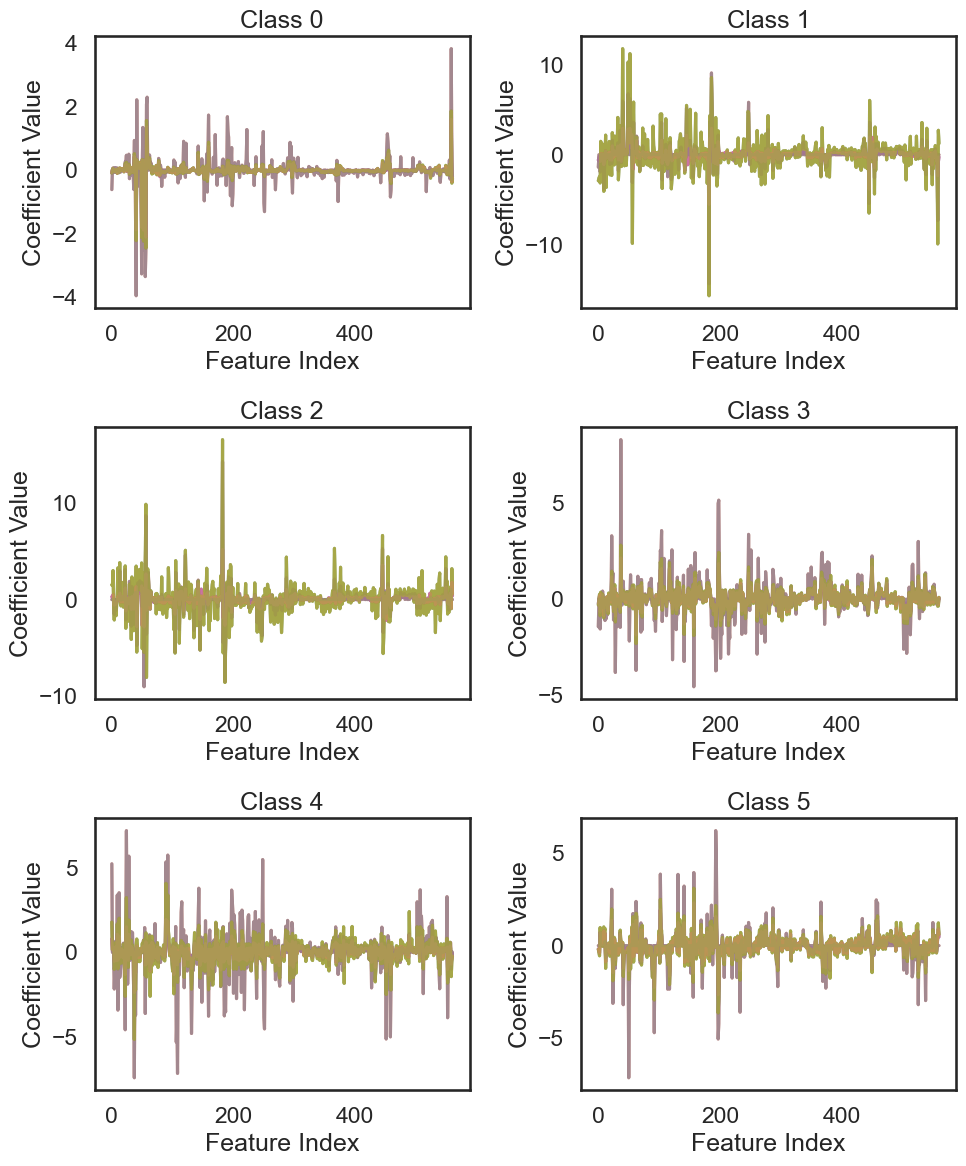

In [51]:
fig, axList = plt.subplots(nrows=3, ncols=2)
axList = axList.flatten()
fig.set_size_inches(10, 12)

for ax, number in zip(axList, range(6)):
    coeff_df = coefficient.iloc[:, coefficient.columns.get_level_values(1)==number]
    coeff_df.plot(ax=ax, alpha=0.5)
    ax.set(title=f'Class {number}', ylabel='Coefficient Value', xlabel='Feature Index')
    ax.legend().set_visible(False)
    
plt.tight_layout()

In [53]:
y_pred = list()
y_prob = list()

for lab, mod in zip(coeff_labels, coeff_models):
    y_pred.append(pd.Series(mod.predict(X_test), name=lab))
    y_prob.append(pd.Series(mod.predict_proba(X_test).max(axis=1), name=lab))

y_pred = pd.concat(y_pred, axis=1)
y_prob = pd.concat(y_prob, axis=1)

y_pred.head()

,lr,l1,l2
0,4,4,4
1,1,1,1
2,4,4,4
3,1,1,1
4,5,5,5


In [54]:
### BEGIN SOLUTION
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

metrics = list()
cm = dict()

for lab in coeff_labels:

    # Preclslon, recall, f-score from the multi-class support function
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted')
    
    # The classracteristic accuracy
    accuracy = accuracy_score(y_test, y_pred[lab])
    
    # ROC-AUC scores can be calculated by binarizing the data
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
                        label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]), 
                        average='weighted', multi_class='ovr')
    
    # Confusion matrix
    cm[lab] = confusion_matrix(y_test, y_pred[lab])
    
    metrics.append(pd.Series({'precision':precision, 'recall':recall, 
                              'fscore':fscore, 'accuracy':accuracy,
                              'auc':auc}, 
                             name=lab))

metrics = pd.concat(metrics, axis=1)

In [55]:
metrics

,lr,l1,l2
precision,0.984780,0.985107,0.986740
recall,0.984790,0.985113,0.986731
fscore,0.984781,0.985104,0.986732
accuracy,0.984790,0.985113,0.986731
auc,0.990760,0.990939,0.991938


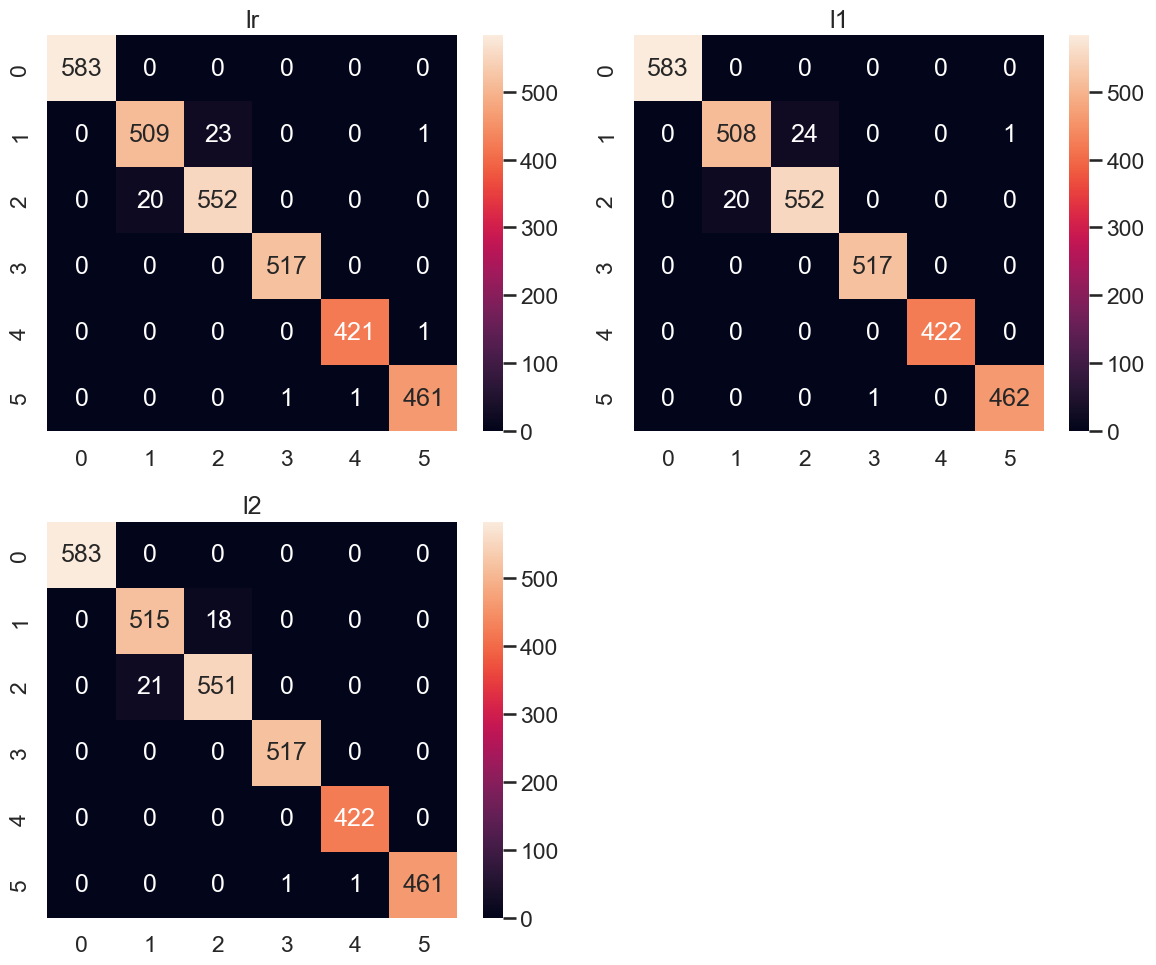

In [56]:
fig, axList = plt.subplots(nrows=2, ncols=2)
axList = axList.flatten()
fig.set_size_inches(12, 10)

axList[-1].axis('off')

for ax,lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d');
    ax.set(title=lab);
    
plt.tight_layout()